In [1]:
import numpy as np
import pandas as pd
import datetime
from sklearn import preprocessing
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# make 8 blobs in 2D space
n_features = 2
centers = 8

X, y = make_blobs(n_samples=1000, centers=centers, n_features=n_features, random_state=68) #rand = 8, 42

data = np.concatenate([X, y.reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=[*[f'feature_{i}' for i in range(n_features)], 'y'])
df['y'] = df['y'].astype(int)

# plot data
plt.figure(dpi=120)
for center in range(centers):
    x1 = df[df['y'] == center]['feature_0']
    x2 = df[df['y'] == center]['feature_1']
    plt.scatter(x1, x2, label=str(center))

plt.legend()
plt.title("Figure 1")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

Text(0, 0.5, 'Feature 2')

In [3]:
df.head()

,feature_0,feature_1,y
0,-5.295432,-9.053238,0
1,2.058577,-5.251177,2
2,3.687847,9.551016,4
3,-3.914157,-8.430547,0
4,2.510445,9.198077,4


In [4]:
# same data with the y column dropped
df_no_labels = df.drop('y',axis=1)

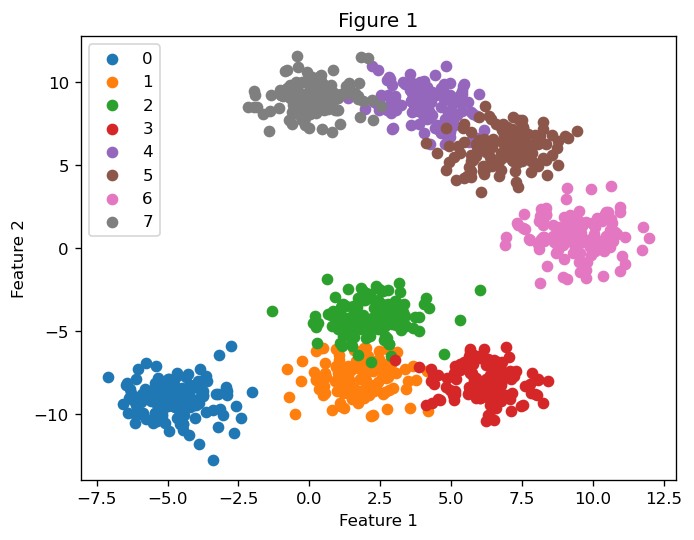

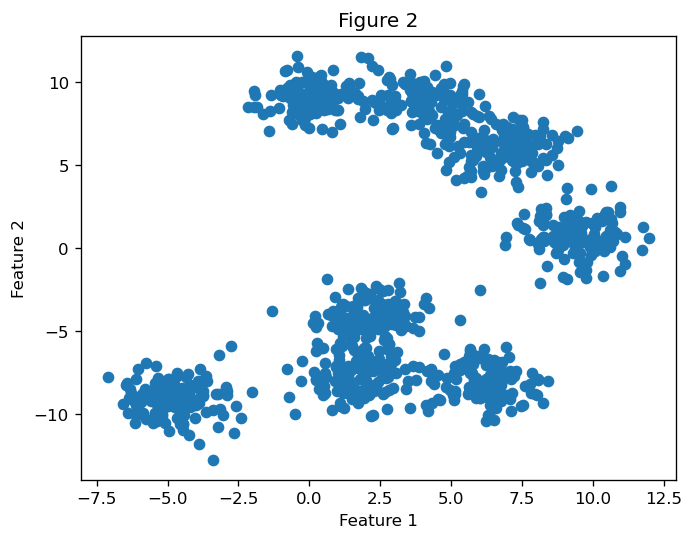

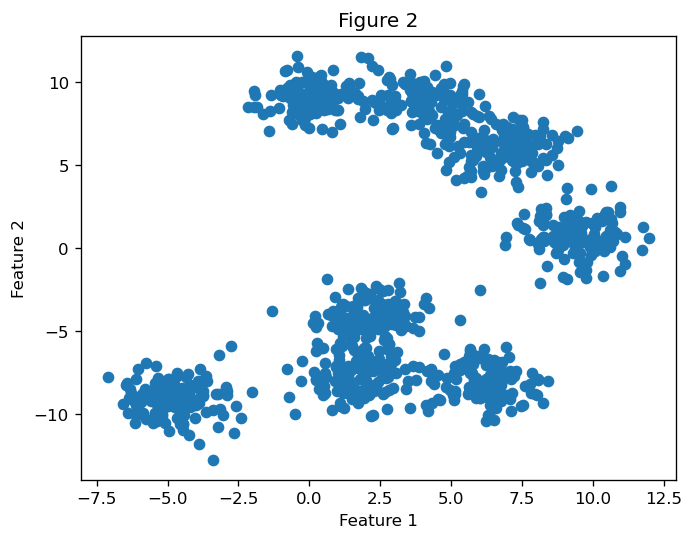

In [6]:
plt.figure(dpi=120)
x1 = df_no_labels['feature_0']
x2 = df_no_labels['feature_1']
plt.scatter(x1, x2)
plt.title("Figure 2")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [7]:
scaler = StandardScaler()

# scale the data
X_scaled = scaler.fit_transform(df_no_labels)

In [8]:
K = 4

In [9]:
from sklearn.cluster import KMeans
# Import time to measure algorithm runtime 
from time import time

In [10]:
km = KMeans(n_clusters=K, random_state=42)
km.fit(X_scaled)

KMeans(n_clusters=4, random_state=42)

In [11]:
# obtain cluster memberships for each item in the data
y_preds = km.predict(X_scaled)
df_no_labels['cluster_label'] = y_preds
centers = scaler.inverse_transform(km.cluster_centers_)

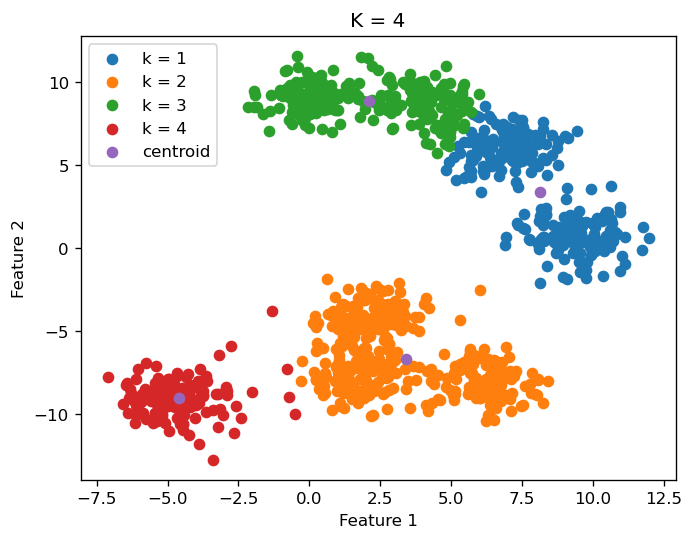

In [12]:
# plot data
plt.figure(dpi=120)
for k in range(K):
    x1 = df_no_labels[df_no_labels['cluster_label'] == k]['feature_0']
    x2 = df_no_labels[df_no_labels['cluster_label'] == k]['feature_1']
    plt.scatter(x1, x2, label="k = "+str(k+1))

# show cluster centroid locations
plt.scatter(centers[:,0],centers[:,1],label="centroid")


plt.legend()
plt.title("K = 4")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [13]:
# Manually implement the WCSS
def within_cluster_variation(df, label_col='label'):
    centroids = df.groupby(label_col).mean()
    out = 0
    for label, point in centroids.iterrows():
        df_features = df[df[label_col] == label].drop(label_col, axis=1)
        out += (df_features - point).pow(2).sum(axis=1).sum()
    return out

In [14]:
# let's try everything between 2 and 20 clusters
n_clusters = np.arange(2, 21)

# store errors for each value of k
errors = []

# for i between 2 and 20
for k in n_clusters:
    # perform k-means clustering
    km = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    km.fit(X_scaled)

    # measure BCSS

    y_preds = km.predict(X_scaled)
    df_no_labels['cluster_label'] = y_preds
    errors.append(within_cluster_variation(df_no_labels,'cluster_label'))

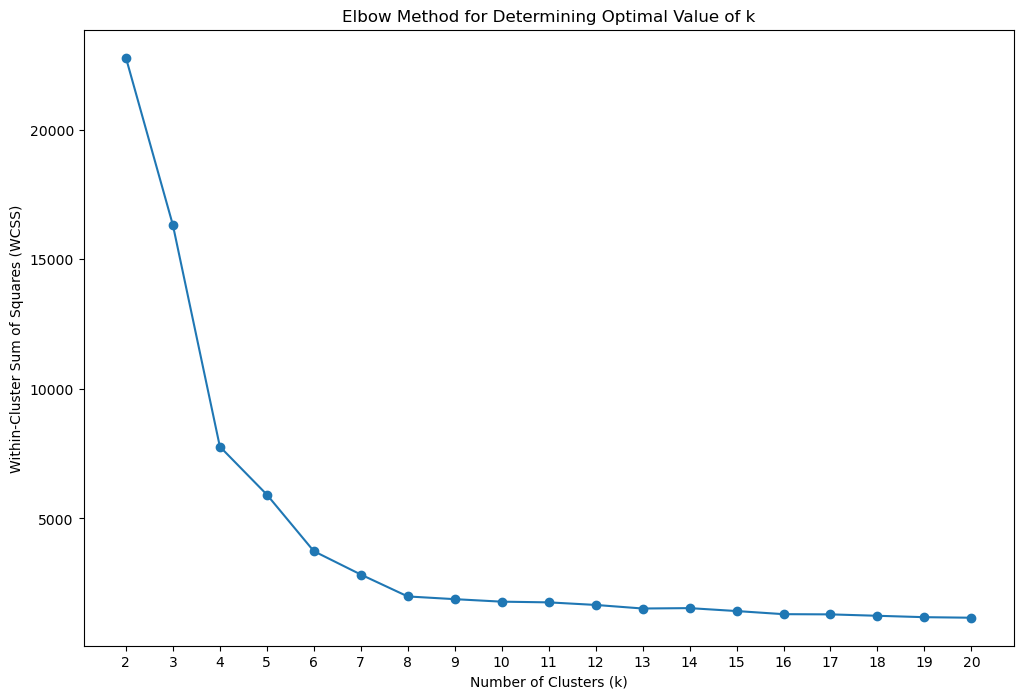

In [15]:
plt.figure(figsize=(12,8))
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Determining Optimal Value of k')
plt.scatter(n_clusters, errors)
plt.plot(n_clusters, errors)
plt.xticks(n_clusters)
plt.show()

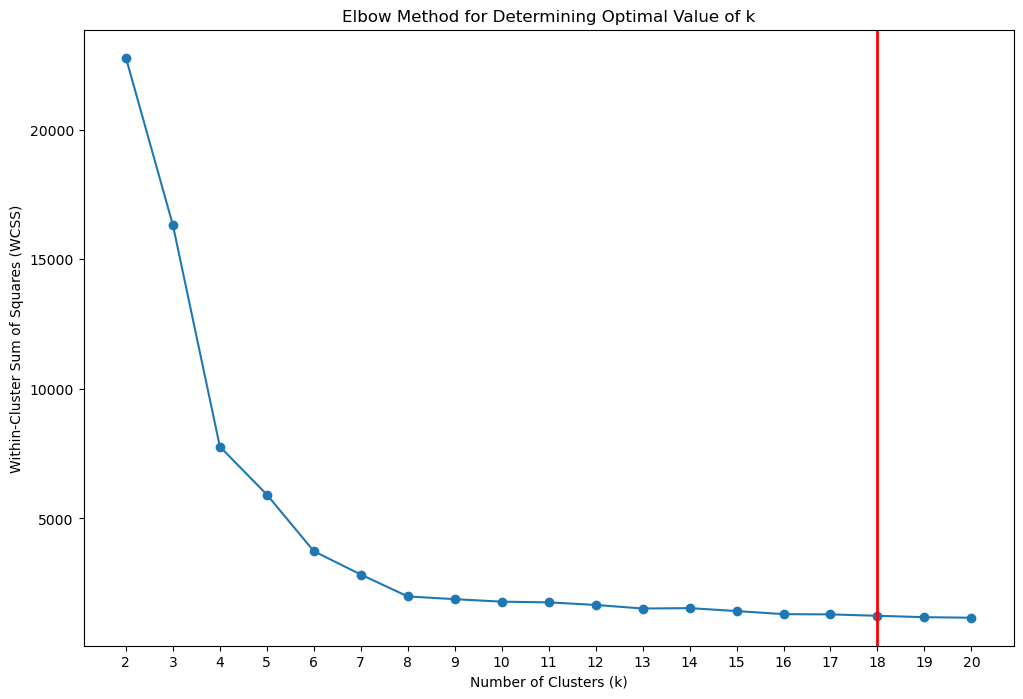

In [17]:
plt.figure(figsize=(12,8))
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Determining Optimal Value of k')
plt.scatter(n_clusters, errors)
plt.plot(n_clusters, errors)
plt.xticks(n_clusters)

plt.axvline(x=18, color='r', lw=2)
plt.show()

In [18]:
K = 6

km = KMeans(n_clusters=K, verbose=0, random_state=42)
print("Clustering sparse data with %s" % km)
t0 = time()
km.fit(X_scaled)
print("done in %0.3fs" % (time() - t0))

Clustering sparse data with KMeans(n_clusters=6, random_state=42)
done in 0.192s


In [19]:
# obtain cluster memberships for each item in the data
y_preds = km.predict(X_scaled)
df_no_labels['cluster_label'] = y_preds
centers = scaler.inverse_transform(km.cluster_centers_)

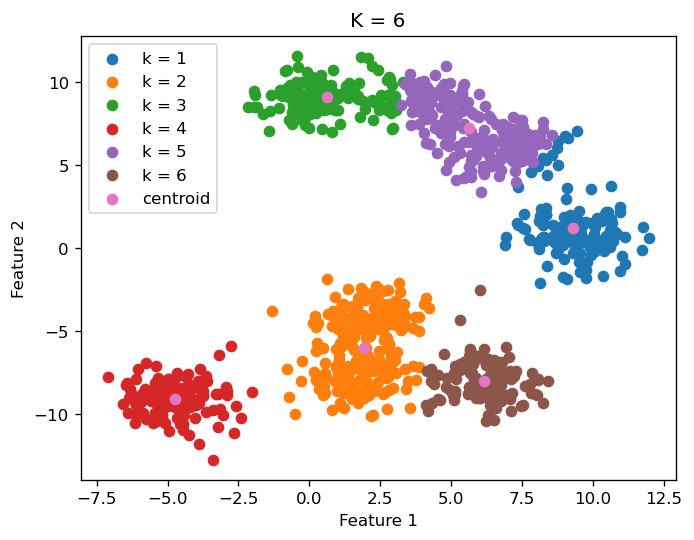

In [20]:
# visualise the clusters
plt.figure(dpi=120)
for k in range(K):
    x1 = df_no_labels[df_no_labels['cluster_label'] == k]['feature_0']
    x2 = df_no_labels[df_no_labels['cluster_label'] == k]['feature_1']
    plt.scatter(x1, x2, label="k = "+str(k+1))

# show cluster centroid locations
plt.scatter(centers[:,0],centers[:,1],label="centroid")


plt.legend()
plt.title("K = 6")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [21]:
# Between cluster variation
def between_cluster_variation(df, label_col='label'):
    centroids = df.groupby(label_col).mean()
    global_mean = df.drop(label_col, axis=1).mean()
    centroid_count = df.groupby(label_col).size()
    centroid_to_mean_dist = (centroids - global_mean).pow(2).sum(axis=1)
    return (centroid_count*centroid_to_mean_dist).sum()

In [22]:
# let's try everything between 2 and 20 clusters
n_clusters = np.arange(2, 21)

# store errors for each value of k
errors = []

# for i between 2 and 20
for k in n_clusters:
    # perform k-means clustering
    km = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    km.fit(X_scaled)

    # measure BCSS

    y_preds = km.predict(X_scaled)
    df_no_labels['cluster_label'] = y_preds
    errors.append(between_cluster_variation(df_no_labels,'cluster_label'))

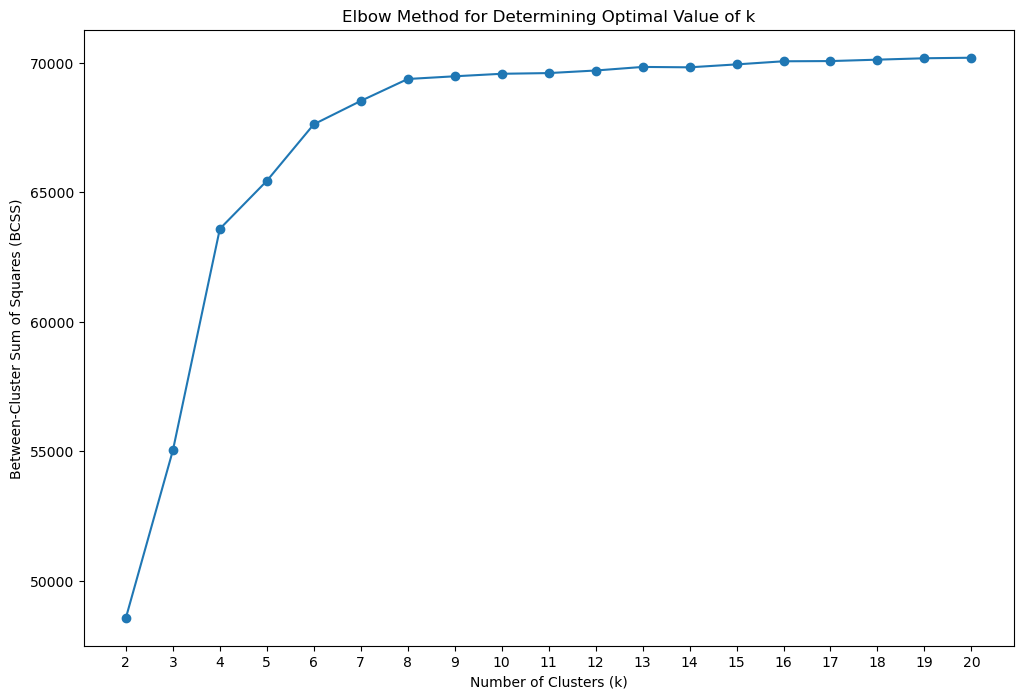

In [23]:
plt.figure(figsize=(12,8))
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Between-Cluster Sum of Squares (BCSS)')
plt.title('Elbow Method for Determining Optimal Value of k')
plt.scatter(n_clusters, errors)
plt.plot(n_clusters, errors)
plt.xticks(n_clusters)
plt.show()

In [24]:
def ch_index(df, label_col='label'):
    n = len(df)
    K = df[label_col].nunique()
    B = between_cluster_variation(df, label_col)
    W = within_cluster_variation(df, label_col)
    return (B / (K-1)) / (W / (n-K))

In [25]:
# let's try everything between 1 and 20 clusters
n_clusters = np.arange(2, 21)

# store errors for each value of k
errors = []

# for i between 1 and 20
for k in n_clusters:
    # perform k-means clustering
    km = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    km.fit(X_scaled)

    # measure CH

    y_preds = km.predict(X_scaled)
    df_no_labels['cluster_label'] = y_preds
    errors.append(ch_index(df_no_labels,'cluster_label'))

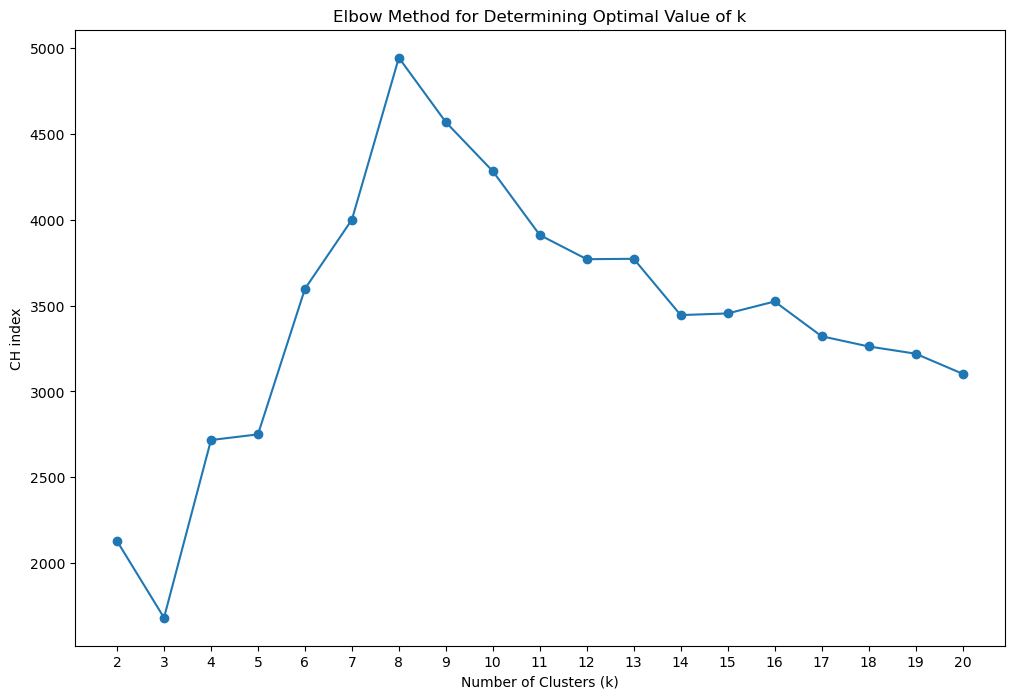

In [26]:
plt.figure(figsize=(12,8))
plt.xlabel('Number of Clusters (k)')
plt.ylabel('CH index')
plt.title('Elbow Method for Determining Optimal Value of k')
plt.scatter(n_clusters, errors)
plt.plot(n_clusters, errors)
plt.xticks(n_clusters)
plt.show()

In [27]:
K = 8
# remember to set the random state for reproducibility
km = KMeans(n_clusters=K, verbose=0, random_state=42)
print("Clustering sparse data with %s" % km)
t0 = time()
km.fit(X_scaled)
print("done in %0.3fs" % (time() - t0))

Clustering sparse data with KMeans(random_state=42)
done in 0.239s


In [28]:
# obtain cluster memberships for each item in the data
y_preds = km.predict(X_scaled)
df_no_labels['cluster_label'] = y_preds
centers = scaler.inverse_transform(km.cluster_centers_)

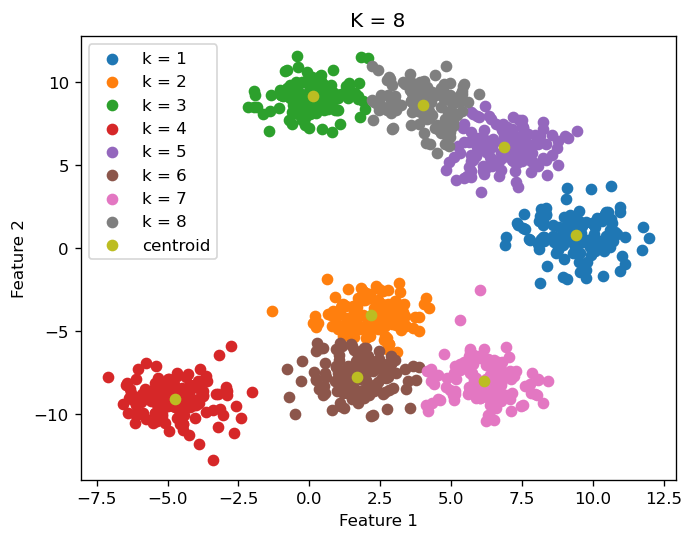

In [29]:
# visualise the clusters
plt.figure(dpi=120)
for k in range(K):
    x1 = df_no_labels[df_no_labels['cluster_label'] == k]['feature_0']
    x2 = df_no_labels[df_no_labels['cluster_label'] == k]['feature_1']
    plt.scatter(x1, x2, label="k = "+str(k+1))

# show cluster centroid locations
plt.scatter(centers[:,0],centers[:,1],label="centroid")


plt.legend()
plt.title("K = 8")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

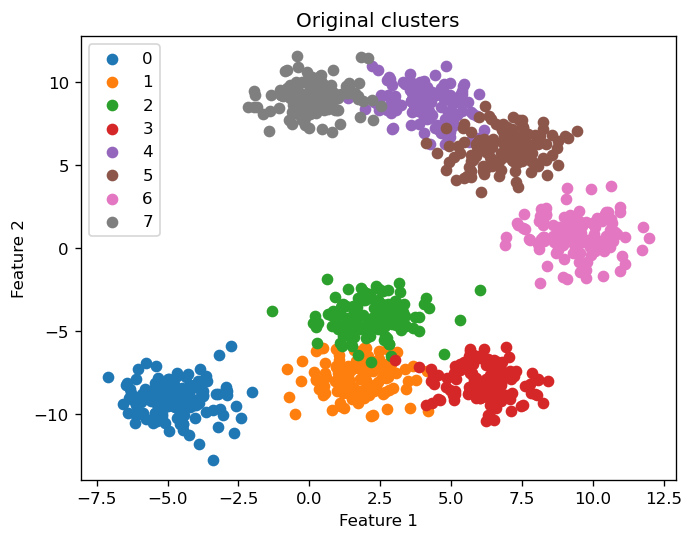

In [30]:
# plot data
plt.figure(dpi=120)
for center in range(8):
    x1 = df[df['y'] == center]['feature_0']
    x2 = df[df['y'] == center]['feature_1']
    plt.scatter(x1, x2, label=str(center))

plt.legend()
plt.title("Original clusters")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [31]:
from sklearn.metrics import silhouette_score
silhouette_avg = silhouette_score(X_scaled, km.labels_)
print("\nSilhouette Score:", silhouette_avg)


Silhouette Score: 0.5756529827045825


In [32]:
from sklearn.metrics import davies_bouldin_score
db_index = davies_bouldin_score(X_scaled, km.labels_)
print("\nDavies-Bouldin Index:", db_index)


Davies-Bouldin Index: 0.5980496802852364
